In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
mc_df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/GitHub/AI-ExpertFW-Prj/dataset/modcloth.xlsx')
mc_df.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [15]:
mc_df.columns = ['item_id', 'waist', 'size', 'quality', 'cup_size', 'hips', 'bra_size',
       'category', 'bust', 'height', 'user_name', 'length', 'fit', 'user_id',
       'shoe_size', 'shoe_width', 'review_summary', 'review_text']

In [16]:
#modcloth_final_data 데이터와 renttherunway데이터 통합을 위한 복사본 생성

mc_df.loc[37313, 'bust'] = 38
mc_df['bust'] = mc_df['bust'].astype('float')

mc_df_cp = mc_df.copy()

In [17]:
#modcloth_final_data 데이터 전처리

mc_df_cp.rename(columns={'quality':'rating', 'bust':'bust_size'}, inplace = True)

mc_df_cp.drop(['shoe_size', 'shoe_width'], axis = 1, inplace = True)

#mc_df_cp.drop(['bra_size'], axis = 1, inplace = True)

mc_df_cp.drop(mc_df_cp[np.isnan(mc_df_cp['rating'])].index, inplace = True)

mc_df_cp.drop(mc_df_cp[mc_df_cp['height'].isnull()].index, inplace = True)

#mc_df_cp.drop(mc_df_cp[(mc_df_cp['review_summary'].isnull()) | (mc_df_cp['review_text'].isnull())].index, inplace = True)

mc_df_cp.drop_duplicates(inplace = True)
#81619 rows × 16 columns -> 81244 rows × 16 columns

mc_df_cp.drop(['waist'], axis = 1, inplace = True)

#mc_df_cp.drop(['waist', 'hips', 'user_name'], axis = 1, inplace = True)

#mc_df_cp['rating'] = mc_df_cp['rating']*2

In [18]:
mc_df_cp.drop(mc_df_cp[mc_df_cp['size'] >= 20].index, inplace = True)


In [19]:
# modcloth_final_data 데이터의 bust_size 가 대다수 누락되어 있으므로
# bust_size 데이터가 누락된 user_id 리스트 중 'fit' == 'fit'이고 'length' == 'just right'인 구매건에 대해 
# 동일한 item_id(item 여러개 구매시 여러개 값 가능), size 들의  'fit' == 'fit'이고 'length' == 'just right'인 다른 구매건에 해당하는 고객의 bust_size 사이즈들의 평균을 구해서 
# bust_size 데이터가 누락된 user_id 리스트 각각에 대입

g_by_userid = mc_df_cp[mc_df_cp['bust_size'].isnull() == True].groupby('user_id', axis = 0).count()

user_missing_cnt = pd.DataFrame({'item_cnt': g_by_userid['item_id']}) 

user_missing_cnt.sort_values(by=['item_cnt'], ascending = False, inplace = True)

user_missing_cnt = user_missing_cnt.rename_axis('user_id').reset_index()

#user_missing_cnt_10 = user_missing_cnt.head(10)


bust_mean = 0.0
new_df = pd.DataFrame(columns = {'user_id', 'item_id', 'bust_mean'})
new_df.drop(new_df.index, axis = 0, inplace = True)

#user_missing_cnt_10로 할 경우 상위 10개 고객에 대한 건만 진행, user_missing_cnt의 경우 누락된 값 가진 모든 user_id에 대해 진행(전체로 했을 시 좀 오래걸림)
for index, row in user_missing_cnt.iterrows():
  item_list = mc_df_cp[(mc_df_cp['user_id'] == row[0]) & (mc_df_cp['length'] == 'just right') & (mc_df_cp['fit'] == 'fit')][['user_id', 'item_id', 'size']]
  item_list.reset_index(drop = True, inplace = True)
  leng = len(item_list)
  for i in range(leng) : 
      bust_mean = mc_df_cp[(mc_df_cp['item_id'] == item_list['item_id'][i]) & (mc_df_cp['fit'] == 'fit') & (mc_df_cp['length'] == 'just right') & (mc_df_cp['size'] == item_list['size'][i])]['bust_size'].mean()
      df_temp = pd.DataFrame({'user_id' : [row[0]], 'item_id' : item_list['item_id'][i], 'bust_mean' : bust_mean})
      new_df = new_df.append(df_temp, ignore_index = True)
#12분 48초 소요

new_df_gby = new_df.groupby('user_id', axis = 0).mean()

for index, row in new_df_gby.iterrows():
    if(np.isnan(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bust_size']).all()):
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bust_size'] = row['bust_mean']
    else : 
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bust_size'] = max(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bust_size'])


In [20]:
# modcloth_final_data 데이터의 hips 가 대다수 누락되어 있으므로
# hips 데이터가 누락된 user_id 리스트 중 'fit' == 'fit'이고 'length' == 'just right'인 구매건에 대해 
# 동일한 item_id(item 여러개 구매시 여러개 값 가능), size 들의  'fit' == 'fit'이고 'length' == 'just right'인 다른 구매건에 해당하는 고객의 hips 사이즈들의 평균을 구해서 
# hips 데이터가 누락된 user_id 리스트 각각에 대입

g_by_userid = mc_df_cp[mc_df_cp['hips'].isnull() == True].groupby('user_id', axis = 0).count()

user_missing_cnt = pd.DataFrame({'item_cnt': g_by_userid['item_id']}) 

user_missing_cnt.sort_values(by=['item_cnt'], ascending = False, inplace = True)

user_missing_cnt = user_missing_cnt.rename_axis('user_id').reset_index()

#user_missing_cnt_10 = user_missing_cnt.head(10)


hip_mean = 0.0
new_df = pd.DataFrame(columns = {'user_id', 'item_id', 'hip_mean'})
new_df.drop(new_df.index, axis = 0, inplace = True)

#user_missing_cnt_10로 할 경우 상위 10개 고객에 대한 건만 진행, user_missing_cnt의 경우 누락된 값 가진 모든 user_id에 대해 진행(전체로 했을 시 좀 오래걸림)
for index, row in user_missing_cnt.iterrows():
  item_list = mc_df_cp[(mc_df_cp['user_id'] == row[0]) & (mc_df_cp['length'] == 'just right') & (mc_df_cp['fit'] == 'fit')][['user_id', 'item_id', 'size']]
  item_list.reset_index(drop = True, inplace = True)
  leng = len(item_list)
  for i in range(leng) : 
      hip_mean = mc_df[(mc_df['item_id'] == item_list['item_id'][i]) & (mc_df['fit'] == 'fit') & (mc_df['length'] == 'just right') & (mc_df['size'] == item_list['size'][i])]['hips'].mean()
      df_temp = pd.DataFrame({'user_id' : [row[0]], 'item_id' : item_list['item_id'][i], 'hip_mean' : hip_mean})
      new_df = new_df.append(df_temp, ignore_index = True)
#12분 48초 소요

new_df_gby = new_df.groupby('user_id', axis = 0).mean()

for index, row in new_df_gby.iterrows():
    if(np.isnan(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'hips']).all()):
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'hips'] = row['hip_mean']
    else : 
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'hips'] = max(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'hips'])


In [21]:
# modcloth_final_data 데이터의 bra_size 가 누락되어 있으므로
# bra_size 데이터가 누락된 user_id 리스트 중 'fit' == 'fit'이고 'length' == 'just right'인 구매건에 대해 
# 동일한 item_id(item 여러개 구매시 여러개 값 가능), size 들의  'fit' == 'fit'이고 'length' == 'just right'인 다른 구매건에 해당하는 고객의 bra_size 사이즈들의 평균을 구해서 
# bra_size 데이터가 누락된 user_id 리스트 각각에 대입

g_by_userid = mc_df_cp[mc_df_cp['bra_size'].isnull() == True].groupby('user_id', axis = 0).count()

user_missing_cnt = pd.DataFrame({'item_cnt': g_by_userid['item_id']}) 

user_missing_cnt.sort_values(by=['item_cnt'], ascending = False, inplace = True)

user_missing_cnt = user_missing_cnt.rename_axis('user_id').reset_index()

#user_missing_cnt_10 = user_missing_cnt.head(10)


bra_mean = 0.0
new_df = pd.DataFrame(columns = {'user_id', 'item_id', 'bra_mean'})
new_df.drop(new_df.index, axis = 0, inplace = True)

#user_missing_cnt_10로 할 경우 상위 10개 고객에 대한 건만 진행, user_missing_cnt의 경우 누락된 값 가진 모든 user_id에 대해 진행(전체로 했을 시 좀 오래걸림)
for index, row in user_missing_cnt.iterrows():
  item_list = mc_df_cp[(mc_df_cp['user_id'] == row[0]) & (mc_df_cp['length'] == 'just right') & (mc_df_cp['fit'] == 'fit')][['user_id', 'item_id', 'size']]
  item_list.reset_index(drop = True, inplace = True)
  leng = len(item_list)
  for i in range(leng) : 
      bra_mean = mc_df_cp[(mc_df_cp['item_id'] == item_list['item_id'][i]) & (mc_df_cp['fit'] == 'fit') & (mc_df_cp['length'] == 'just right') & (mc_df_cp['size'] == item_list['size'][i])]['bra_size'].mean()
      df_temp = pd.DataFrame({'user_id' : [row[0]], 'item_id' : item_list['item_id'][i], 'bra_mean' : bra_mean})
      new_df = new_df.append(df_temp, ignore_index = True)
#12분 48초 소요

new_df_gby = new_df.groupby('user_id', axis = 0).mean()

for index, row in new_df_gby.iterrows():
    if(np.isnan(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bra_size']).all()):
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bra_size'] = row['bra_mean']
    else : 
        mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bra_size'] = max(mc_df_cp.loc[mc_df_cp['user_id'] == index, 'bra_size'])


In [22]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/GitHub/AI-ExpertFW-Prj/dataset')

In [23]:
mc_df_cp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 63157 entries, 0 to 82789
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         63157 non-null  int64  
 1   size            63157 non-null  int64  
 2   rating          63157 non-null  float64
 3   cup_size        58742 non-null  object 
 4   hips            57213 non-null  float64
 5   bra_size        61644 non-null  float64
 6   category        63157 non-null  object 
 7   bust_size       46948 non-null  float64
 8   height          63157 non-null  object 
 9   user_name       63157 non-null  object 
 10  length          63141 non-null  object 
 11  fit             63157 non-null  object 
 12  user_id         63157 non-null  int64  
 13  review_summary  58259 non-null  object 
 14  review_text     58259 non-null  object 
dtypes: float64(4), int64(3), object(8)
memory usage: 7.7+ MB


In [24]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/GitHub/AI-ExpertFW-Prj/dataset')
mc_df_cp.to_excel('modcloth_preprocessing.xlsx', index = False)

In [26]:
modcloth_preprocessing = pd.read_excel('modcloth_preprocessing.xlsx')

,item_id,size,rating,cup_size,hips,bra_size,category,bust_size,height,user_name,length,fit,user_id,review_summary,review_text
0,123373,7,5,d,38.000000,34.000000,new,36.000000,5ft 6in,Emily,just right,small,991571,NaN,NaN
1,123373,13,3,b,30.000000,36.000000,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN
2,123373,7,2,b,NaN,32.000000,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,NaN,NaN
3,123373,18,5,b,NaN,36.000000,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN
4,123373,11,5,c,41.000000,36.000000,new,NaN,5ft 4in,Doreenajane,just right,small,162012,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63152,807722,8,4,b,37.008308,36.000000,outerwear,35.475561,5ft 8in,Jennifer,just right,fit,727820,Cute jacket!,Cute jacket!
63153,807722,12,5,ddd/f,NaN,34.000000,outerwear,NaN,5ft 5in,Kelli,slightly long,small,197040,It's a beautiful jacket.,It's a beautiful jacket. I love how it's knit ...
63154,807722,12,5,dddd/g,36.000000,32.000000,outerwear,36.000000,5ft 4in,elacount,just right,fit,102493,I love this blazer. It is,I love this blazer. It is a great office piece...
63155,807722,12,4,NaN,39.226685,35.474022,outerwear,37.437500,5ft 3in,jennaklinner,just right,fit,756491,I love this blazer!! I wo,I love this blazer!! I wore it yesterday and g...


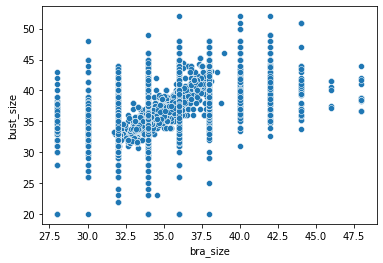

In [27]:
import seaborn as sns
sns.scatterplot(x='bra_size', y='bust_size', data=modcloth_preprocessing)